 # MNIST Digit Recognition with ONNX Export

 ## 1. Setup & Data Loading

This section imports the necessary libraries, downloads the MNIST dataset, and prepares it for training and testing. Standard normalization is applied to the image data.


In [10]:
!pip install onnx onnxscript
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import onnx

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Hyperparameters
num_epochs = 20
batch_size = 64
learning_rate = 0.001

# 1. Aggressive Data Augmentation
train_transform = transforms.Compose([
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.85, 1.15)),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.5),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load datasets
full_train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=train_transform, download=True)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, transform=test_transform)

# Validation split
train_size = int(0.9 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(full_train_dataset, [train_size, val_size])

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

print(f"Device: {device}. Training: {len(train_dataset)}, Validation: {len(val_dataset)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 19.8 MB/s eta 0:00:00
Device: cuda. Training: 54000, Validation: 6000


 ## 2. Model Architecture

Here, we define a simple Convolutional Neural Network (CNN) consisting of two convolutional layers followed by max-pooling, and two fully connected linear layers. The input expects a 1x28x28 grayscale image, and the output provides scores for 10 classes (digits 0-9).


In [7]:
class EdgeOptimizedCNN(nn.Module):
    def __init__(self):
        super(EdgeOptimizedCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout1 = nn.Dropout(0.25)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 14 * 14, 128)
        self.bn3 = nn.BatchNorm1d(128)
        self.dropout2 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)
        x = self.dropout1(x)
        x = self.flatten(x)
        x = F.relu(self.bn3(self.fc1(x)))
        x = self.dropout2(x)
        return self.fc2(x)

# Ensure device is defined even if first cell execution was partial
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = EdgeOptimizedCNN().to(device)
print("Model initialized successfully.")

Model initialized successfully.


 ## 3. Training Loop

This section defines the loss function and optimizer, and then runs the training loop for a specified number of epochs. It calculates and prints the training loss and accuracy at regular intervals.


In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2, factor=0.5)

best_val_loss = float('inf')
patience_early_stopping = 5
trigger_times = 0

for epoch in range(num_epochs):
    model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()

    model.eval()
    val_loss, correct = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            val_loss += criterion(outputs, labels).item()
            correct += (outputs.argmax(1) == labels).sum().item()

    avg_val_loss = val_loss / len(val_loader)
    print(f'Epoch [{epoch+1}/{num_epochs}], Val Acc: {100*correct/len(val_dataset):.2f}%')
    scheduler.step(avg_val_loss)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), 'best_model.pth')
        trigger_times = 0
    else:
        trigger_times += 1
        if trigger_times >= patience_early_stopping: break

model.load_state_dict(torch.load('best_model.pth'))

Epoch [1/20], Val Acc: 95.37%
Epoch [2/20], Val Acc: 96.28%
Epoch [3/20], Val Acc: 96.22%
Epoch [4/20], Val Acc: 96.97%
Epoch [5/20], Val Acc: 97.02%
Epoch [6/20], Val Acc: 96.85%
Epoch [7/20], Val Acc: 98.05%
Epoch [8/20], Val Acc: 97.57%
Epoch [9/20], Val Acc: 98.12%
Epoch [10/20], Val Acc: 98.22%
Epoch [11/20], Val Acc: 98.08%
Epoch [12/20], Val Acc: 98.22%
Epoch [13/20], Val Acc: 98.22%
Epoch [14/20], Val Acc: 97.82%
Epoch [15/20], Val Acc: 98.07%
Epoch [16/20], Val Acc: 98.28%
Epoch [17/20], Val Acc: 98.58%
Epoch [18/20], Val Acc: 98.63%
Epoch [19/20], Val Acc: 98.78%
Epoch [20/20], Val Acc: 98.53%


<All keys matched successfully>

 ## 4. ONNX Export

This crucial step exports the trained PyTorch model to the ONNX (Open Neural Network Exchange) format. We create a dummy input tensor and specify `input_names`, `output_names`, and `dynamic_axes` to ensure the exported ONNX model is flexible for various batch sizes in web deployment.


In [11]:
import torch
import onnx

# Ensure model and device are available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if 'model' not in globals():
    print("Re-initializing model architecture...")
    model = EdgeOptimizedCNN().to(device)
    if torch.os.path.exists('best_model.pth'):
        model.load_state_dict(torch.load('best_model.pth'))

model.eval()
onnx_file_name = "mnist_model.onnx"
dummy_input = torch.randn(1, 1, 28, 28).to(device)

# Strict ONNX Export Pipeline
torch.onnx.export(
    model,
    dummy_input,
    onnx_file_name,
    export_params=True,
    opset_version=12,
    do_constant_folding=True,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}}
)

# Verification
onnx_model = onnx.load(onnx_file_name)
onnx.checker.check_model(onnx_model)
print(f"Success: Robust model exported to {onnx_file_name}")

/tmp/ipykernel_3640/1190482143.py:17: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0411 13:28:36.264000 3640 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 12 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0411 13:28:37.190000 3640 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, a

[torch.onnx] Obtain model graph for `EdgeOptimizedCNN([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `EdgeOptimizedCNN([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 4 of general pattern rewrite rules.
Success: Robust model exported to mnist_model.onnx


## 5. Comprehensive Model Evaluation

To ensure the model is truly robust for real-world deployment, we will now perform a detailed evaluation. This includes calculating a confusion matrix to see which digits are most frequently confused and visualizing predictions on the test set.

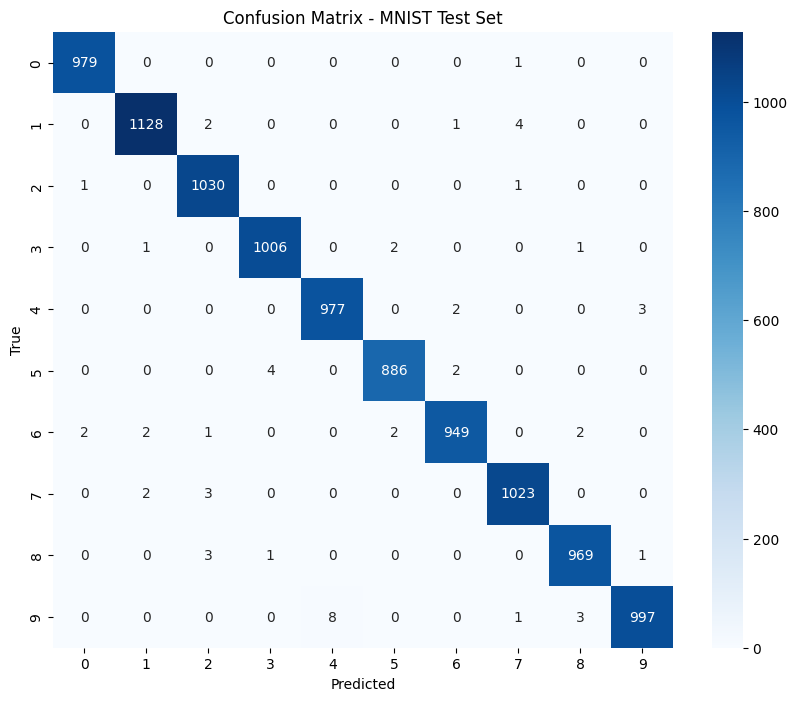


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       1.00      0.99      0.99      1135
           2       0.99      1.00      0.99      1032
           3       1.00      1.00      1.00      1010
           4       0.99      0.99      0.99       982
           5       1.00      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      1.00      0.99      1028
           8       0.99      0.99      0.99       974
           9       1.00      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def evaluate_model(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_labels), np.array(all_preds)

# Get predictions
y_true, y_pred = evaluate_model(model, test_loader, device)

# Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - MNIST Test Set')
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

### 5.1 Visualizing Predictions
Let's visualize how the model performs on actual samples from the test set, including the probability distribution for each prediction.

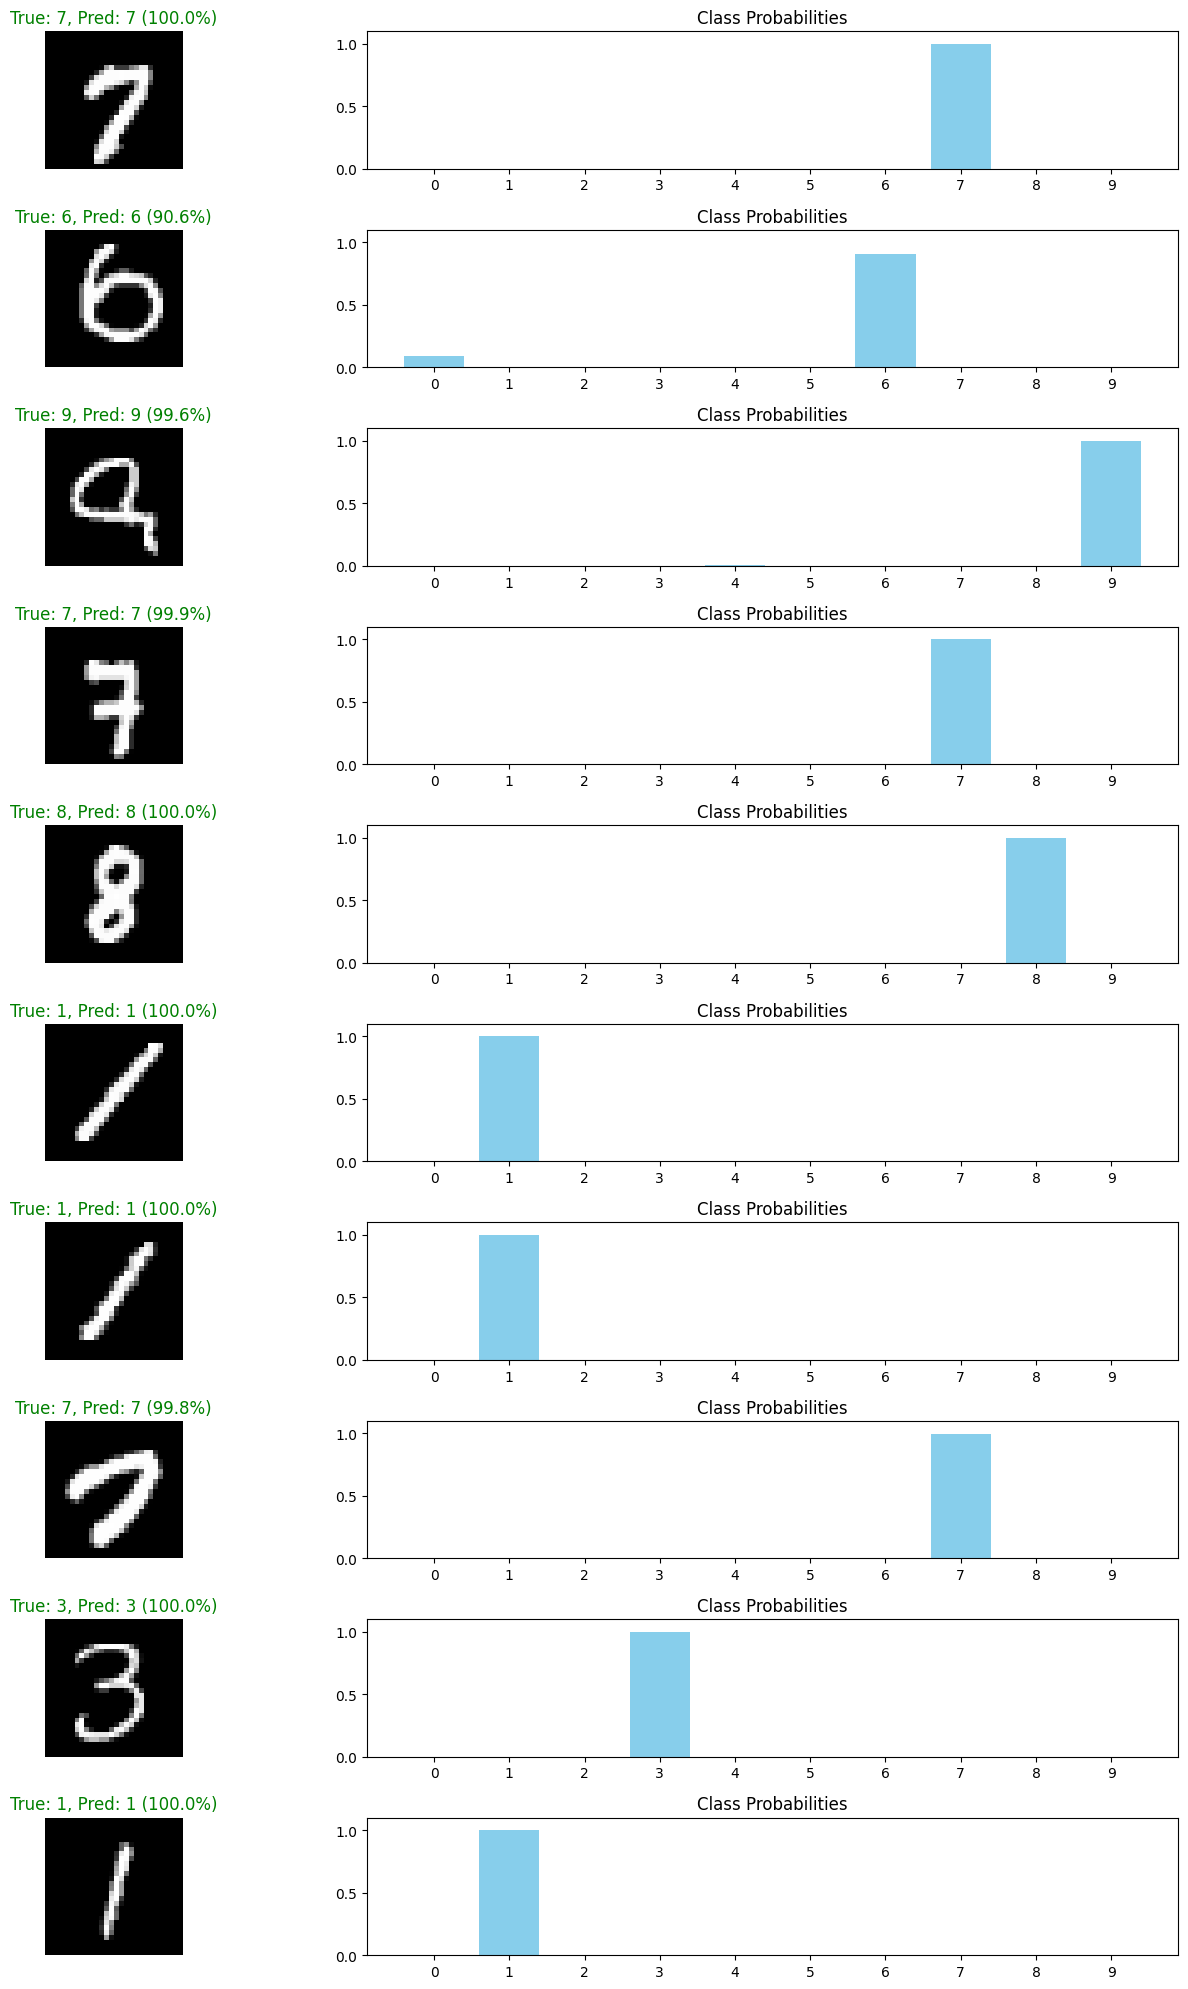

In [13]:
def visualize_predictions(model, dataset, device, num_samples=10):
    model.eval()
    indices = np.random.choice(len(dataset), num_samples, replace=False)

    plt.figure(figsize=(15, num_samples * 2))

    for i, idx in enumerate(indices):
        image, label = dataset[idx]
        input_tensor = image.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(input_tensor)
            probabilities = F.softmax(output, dim=1).cpu().numpy()[0]
            prediction = np.argmax(probabilities)

        # Plot Image
        plt.subplot(num_samples, 2, 2*i + 1)
        plt.imshow(image.squeeze(), cmap='gray')
        color = 'green' if prediction == label else 'red'
        plt.title(f"True: {label}, Pred: {prediction} ({probabilities[prediction]*100:.1f}%)", color=color)
        plt.axis('off')

        # Plot Probabilities
        plt.subplot(num_samples, 2, 2*i + 2)
        plt.bar(range(10), probabilities, color='skyblue')
        plt.xticks(range(10))
        plt.ylim(0, 1.1)
        plt.title("Class Probabilities")

    plt.tight_layout()
    plt.show()

visualize_predictions(model, test_dataset, device)

## 6. Performance & Efficiency Analysis

In edge deployment (like web browsers), model size and inference speed are critical. This section calculates the total parameters and measures latency.

Total Trainable Parameters: 1,626,314
Average Inference Latency (Single Image): 0.5067 ms


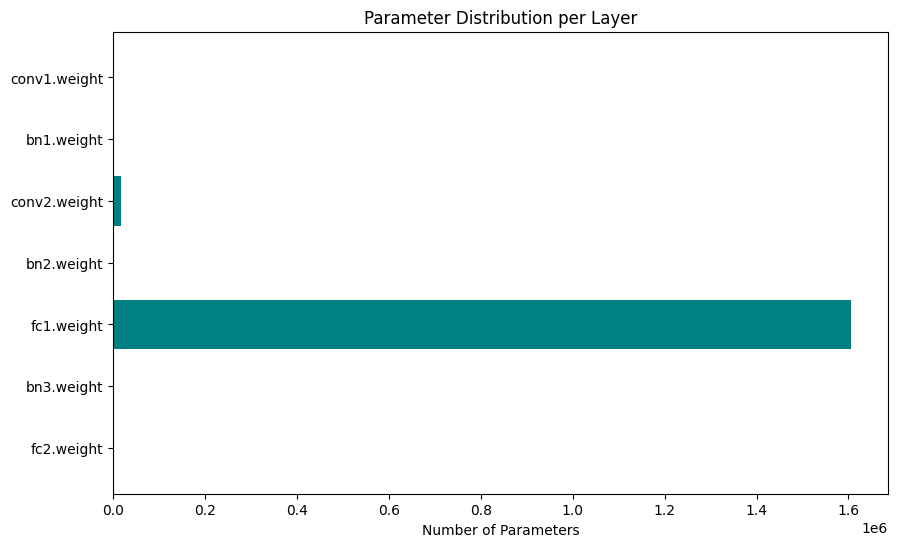

In [15]:
import time

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def measure_latency(model, device, num_runs=100):
    model.eval()
    dummy_input = torch.randn(1, 1, 28, 28).to(device)

    # Warm up
    for _ in range(10):
        _ = model(dummy_input)

    start_time = time.time()
    with torch.no_grad():
        for _ in range(num_runs):
            _ = model(dummy_input)
    end_time = time.time()

    avg_latency = (end_time - start_time) / num_runs
    return avg_latency

params = count_parameters(model)
latency = measure_latency(model, device)

print(f"Total Trainable Parameters: {params:,}")
print(f"Average Inference Latency (Single Image): {latency*1000:.4f} ms")

# Visualization of Parameter Distribution
layer_names = [name for name, _ in model.named_parameters() if 'weight' in name]
param_counts = [p.numel() for name, p in model.named_parameters() if 'weight' in name]

plt.figure(figsize=(10, 6))
plt.barh(layer_names, param_counts, color='teal')
plt.xlabel('Number of Parameters')
plt.title('Parameter Distribution per Layer')
plt.gca().invert_yaxis()
plt.show()

## 7. Stress Testing with Synthetic Noise

To further validate robustness, we can add Gaussian noise to a test image and see if the model still correctly identifies the digit. This simulates low-quality input sensors.

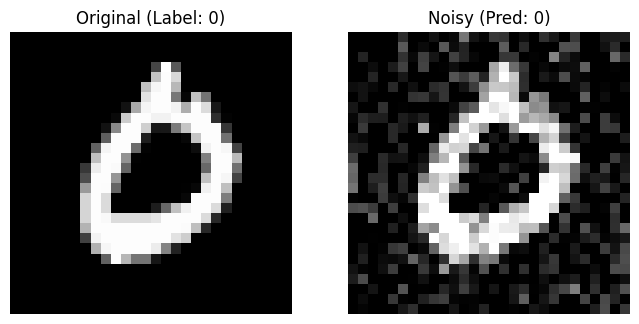

✅ Model successfully handled the noise!


In [16]:
def test_with_noise(model, dataset, device, noise_level=0.2):
    model.eval()
    idx = np.random.randint(len(dataset))
    image, label = dataset[idx]

    # Add noise
    noisy_image = image + torch.randn(image.size()) * noise_level
    noisy_image = torch.clamp(noisy_image, -1, 1)

    input_tensor = noisy_image.unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(input_tensor)
        prediction = torch.argmax(output, 1).item()

    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(image.squeeze(), cmap='gray')
    plt.title(f"Original (Label: {label})")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(noisy_image.squeeze(), cmap='gray')
    plt.title(f"Noisy (Pred: {prediction})")
    plt.axis('off')
    plt.show()

    if prediction == label:
        print("✅ Model successfully handled the noise!")
    else:
        print("❌ Model failed on noisy input.")

test_with_noise(model, test_dataset, device, noise_level=0.4)